In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv(r"C:\Users\VIJI\Downloads\financial_trans.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Transaction_ID      94982 non-null   object 
 1   Transaction_Date    95120 non-null   object 
 2   Customer_ID         95122 non-null   object 
 3   Product_Name        100000 non-null  object 
 4   Quantity            94981 non-null   float64
 5   Price               66503 non-null   object 
 6   Payment_Method      100000 non-null  object 
 7   Transaction_Status  83321 non-null   object 
dtypes: float64(1), object(7)
memory usage: 6.1+ MB


In [4]:
df.shape

(100000, 8)

In [5]:
df.describe()

,Quantity
count,94981.000000
mean,183.883914
std,299.292365
min,-10.000000
25%,-3.000000
50%,6.000000
75%,327.000000
max,1000.000000


In [6]:
df.isnull().sum()

Transaction_ID         5018
Transaction_Date       4880
Customer_ID            4878
Product_Name              0
Quantity               5019
Price                 33497
Payment_Method            0
Transaction_Status    16679
dtype: int64

In [7]:
df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
0,T0001,2024-08-02,C2205,Headphones,-5.0,$420.21,pay pal,NaN
1,T0002,2020-02-10,C3156,Coffee,469.0,-445.34202525395585,creditcard,Pending
2,T0003,2025-02-30,C2919,Tablet,-4.0,810.9930123946459,credit card,completed
3,T0004,2020-08-17,C3009,Tab,-7.0,868.6083413217348,PayPal,Pending
4,T0005,2025-02-30,C3488,Coffee Machine,-10.0,-763.1224490039416,PayPal,completed


In [8]:
#to fill null values in numerical column using  median
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Transaction_ID      94982 non-null   object 
 1   Transaction_Date    95120 non-null   object 
 2   Customer_ID         95122 non-null   object 
 3   Product_Name        100000 non-null  object 
 4   Quantity            100000 non-null  float64
 5   Price               66503 non-null   object 
 6   Payment_Method      100000 non-null  object 
 7   Transaction_Status  83321 non-null   object 
dtypes: float64(1), object(7)
memory usage: 6.1+ MB


In [10]:
df['Transaction_Date'].unique()

array(['2024-08-02', '2020-02-10', '2025-02-30', ..., '2020-09-01',
       '2023-05-31', '2023-09-13'], dtype=object)

In [11]:
import warnings
warnings.filterwarnings('ignore')

In [12]:
# to remove null valueds in categorical column by using mode
cate_cols = df.select_dtypes(include='object').columns

for col in cate_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Transaction_ID      100000 non-null  object 
 1   Transaction_Date    100000 non-null  object 
 2   Customer_ID         100000 non-null  object 
 3   Product_Name        100000 non-null  object 
 4   Quantity            100000 non-null  float64
 5   Price               100000 non-null  object 
 6   Payment_Method      100000 non-null  object 
 7   Transaction_Status  100000 non-null  object 
dtypes: float64(1), object(7)
memory usage: 6.1+ MB


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Transaction_ID      100000 non-null  object 
 1   Transaction_Date    100000 non-null  object 
 2   Customer_ID         100000 non-null  object 
 3   Product_Name        100000 non-null  object 
 4   Quantity            100000 non-null  float64
 5   Price               100000 non-null  object 
 6   Payment_Method      100000 non-null  object 
 7   Transaction_Status  100000 non-null  object 
dtypes: float64(1), object(7)
memory usage: 6.1+ MB


In [15]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999     True
Length: 100000, dtype: bool

In [16]:
df.duplicated().sum()

994

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
99994    False
99995    False
99996    False
99997    False
99998    False
Length: 99006, dtype: bool

In [19]:
df['Transaction_Date'].str.split('-').str[0].head()

0    2024
1    2020
2    2025
3    2020
4    2025
Name: Transaction_Date, dtype: object

In [20]:
df['Year']=df['Transaction_Date'].str.split('-').str[0]
df['Month']=df['Transaction_Date'].str.split('-').str[1]
df['Date']=df['Transaction_Date'].str.split('-').str[2]


In [21]:
df['Month'].value_counts()

Month
13    36333
02    33704
01     3191
12     2705
05     2687
09     2612
06     2610
07     2597
08     2562
03     2560
10     2529
04     2470
11     2446
Name: count, dtype: int64

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99006 entries, 0 to 99998
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      99006 non-null  object 
 1   Transaction_Date    99006 non-null  object 
 2   Customer_ID         99006 non-null  object 
 3   Product_Name        99006 non-null  object 
 4   Quantity            99006 non-null  float64
 5   Price               99006 non-null  object 
 6   Payment_Method      99006 non-null  object 
 7   Transaction_Status  99006 non-null  object 
 8   Year                99006 non-null  object 
 9   Month               99006 non-null  object 
 10  Date                99006 non-null  object 
dtypes: float64(1), object(10)
memory usage: 9.1+ MB


In [23]:
df.head(10)

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status,Year,Month,Date
0,T0001,2024-08-02,C2205,Headphones,-5.0,$420.21,pay pal,Failed,2024,08,02
1,T0002,2020-02-10,C3156,Coffee,469.0,-445.34202525395585,creditcard,Pending,2020,02,10
2,T0003,2025-02-30,C2919,Tablet,-4.0,810.9930123946459,credit card,completed,2025,02,30
3,T0004,2020-08-17,C3009,Tab,-7.0,868.6083413217348,PayPal,Pending,2020,08,17
4,T0005,2025-02-30,C3488,Coffee Machine,-10.0,-763.1224490039416,PayPal,completed,2025,02,30
5,T0006,2021-10-26,C4241,Smartphone,598.0,$-260.08,PayPal,Completed,2021,10,26
6,T1258,2025-02-30,C1313,Laptop,10.0,$-260.08,credit card,Completed,2025,02,30
7,T0008,2023-13-01,C4736,Headphones,669.0,-86.92126929493884,Cash,Failed,2023,13,01
8,T0009,2023-13-01,C3387,Tablet,10.0,461.70198437439694,PayPal,Failed,2023,13,01
9,T0010,2025-02-30,C2846,Laptop,-1.0,404.8907066405689,creditcard,Pending,2025,02,30


In [24]:
df['Month'].unique()

array(['08', '02', '10', '13', '03', '06', '07', '11', '01', '04', '12',
       '05', '09'], dtype=object)

In [25]:
df[df['Month']=='13']

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status,Year,Month,Date
7,T0008,2023-13-01,C4736,Headphones,669.0,-86.92126929493884,Cash,Failed,2023,13,01
8,T0009,2023-13-01,C3387,Tablet,10.0,461.70198437439694,PayPal,Failed,2023,13,01
10,T0011,2023-13-01,C1004,Laptop,10.0,-600.8393093751704,PayPal,complete,2023,13,01
11,T0012,2023-13-01,C2912,Tablet,608.0,$-260.08,PayPal,completed,2023,13,01
21,T0022,2023-13-01,C3883,Smartphone,9.0,$-260.08,creditcard,Completed,2023,13,01
...,...,...,...,...,...,...,...,...,...,...,...
99969,T99970,2023-13-01,C153,La,-6.0,82.47380935452588,Credit Card,completed,2023,13,01
99973,T1258,2023-13-01,C918,Coffee Machine,702.0,$-260.08,credit card,Pending,2023,13,01
99981,T99982,2023-13-01,C4049,Laptop,2.0,-204.9329818590478,Cash,Failed,2023,13,01
99990,T99991,2023-13-01,C4555,Tab,2.0,131.0368687292207,pay pal,Failed,2023,13,01


In [26]:
df['Date'].unique()

array(['02', '10', '30', '17', '26', '01', '18', '19', '07', '03', '16',
       '05', '25', '20', '04', '23', '22', '15', '28', '31', '24', '06',
       '08', '29', '14', '12', '13', '11', '09', '21', '27'], dtype=object)

In [27]:
df[df['Month']=='13']

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status,Year,Month,Date
7,T0008,2023-13-01,C4736,Headphones,669.0,-86.92126929493884,Cash,Failed,2023,13,01
8,T0009,2023-13-01,C3387,Tablet,10.0,461.70198437439694,PayPal,Failed,2023,13,01
10,T0011,2023-13-01,C1004,Laptop,10.0,-600.8393093751704,PayPal,complete,2023,13,01
11,T0012,2023-13-01,C2912,Tablet,608.0,$-260.08,PayPal,completed,2023,13,01
21,T0022,2023-13-01,C3883,Smartphone,9.0,$-260.08,creditcard,Completed,2023,13,01
...,...,...,...,...,...,...,...,...,...,...,...
99969,T99970,2023-13-01,C153,La,-6.0,82.47380935452588,Credit Card,completed,2023,13,01
99973,T1258,2023-13-01,C918,Coffee Machine,702.0,$-260.08,credit card,Pending,2023,13,01
99981,T99982,2023-13-01,C4049,Laptop,2.0,-204.9329818590478,Cash,Failed,2023,13,01
99990,T99991,2023-13-01,C4555,Tab,2.0,131.0368687292207,pay pal,Failed,2023,13,01


In [28]:
df.head(10)


,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status,Year,Month,Date
0,T0001,2024-08-02,C2205,Headphones,-5.0,$420.21,pay pal,Failed,2024,08,02
1,T0002,2020-02-10,C3156,Coffee,469.0,-445.34202525395585,creditcard,Pending,2020,02,10
2,T0003,2025-02-30,C2919,Tablet,-4.0,810.9930123946459,credit card,completed,2025,02,30
3,T0004,2020-08-17,C3009,Tab,-7.0,868.6083413217348,PayPal,Pending,2020,08,17
4,T0005,2025-02-30,C3488,Coffee Machine,-10.0,-763.1224490039416,PayPal,completed,2025,02,30
5,T0006,2021-10-26,C4241,Smartphone,598.0,$-260.08,PayPal,Completed,2021,10,26
6,T1258,2025-02-30,C1313,Laptop,10.0,$-260.08,credit card,Completed,2025,02,30
7,T0008,2023-13-01,C4736,Headphones,669.0,-86.92126929493884,Cash,Failed,2023,13,01
8,T0009,2023-13-01,C3387,Tablet,10.0,461.70198437439694,PayPal,Failed,2023,13,01
9,T0010,2025-02-30,C2846,Laptop,-1.0,404.8907066405689,creditcard,Pending,2025,02,30


In [29]:
df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status,Year,Month,Date
0,T0001,2024-08-02,C2205,Headphones,-5.0,$420.21,pay pal,Failed,2024,08,02
1,T0002,2020-02-10,C3156,Coffee,469.0,-445.34202525395585,creditcard,Pending,2020,02,10
2,T0003,2025-02-30,C2919,Tablet,-4.0,810.9930123946459,credit card,completed,2025,02,30
3,T0004,2020-08-17,C3009,Tab,-7.0,868.6083413217348,PayPal,Pending,2020,08,17
4,T0005,2025-02-30,C3488,Coffee Machine,-10.0,-763.1224490039416,PayPal,completed,2025,02,30


In [30]:
df['Date']=df['Transaction_Date'].str.split('-').str[2]
df['Month']=df['Transaction_Date'].str.split('-').str[1]
df['Year']=df['Transaction_Date'].str.split('-').str[0]


In [31]:
df['Date'].unique()

array(['02', '10', '30', '17', '26', '01', '18', '19', '07', '03', '16',
       '05', '25', '20', '04', '23', '22', '15', '28', '31', '24', '06',
       '08', '29', '14', '12', '13', '11', '09', '21', '27'], dtype=object)

In [32]:
df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status,Year,Month,Date
0,T0001,2024-08-02,C2205,Headphones,-5.0,$420.21,pay pal,Failed,2024,08,02
1,T0002,2020-02-10,C3156,Coffee,469.0,-445.34202525395585,creditcard,Pending,2020,02,10
2,T0003,2025-02-30,C2919,Tablet,-4.0,810.9930123946459,credit card,completed,2025,02,30
3,T0004,2020-08-17,C3009,Tab,-7.0,868.6083413217348,PayPal,Pending,2020,08,17
4,T0005,2025-02-30,C3488,Coffee Machine,-10.0,-763.1224490039416,PayPal,completed,2025,02,30


In [33]:
df['Month'].unique()

array(['08', '02', '10', '13', '03', '06', '07', '11', '01', '04', '12',
       '05', '09'], dtype=object)

In [34]:
df['Month'].unique()

array(['08', '02', '10', '13', '03', '06', '07', '11', '01', '04', '12',
       '05', '09'], dtype=object)

In [35]:
df['Month'].value_counts()

Month
13    36333
02    33704
01     3191
12     2705
05     2687
09     2612
06     2610
07     2597
08     2562
03     2560
10     2529
04     2470
11     2446
Name: count, dtype: int64

In [36]:
df.loc[df['Month'] == 13, 'Month'] = 12

In [37]:
df['Month'].value_counts()

Month
13    36333
02    33704
01     3191
12     2705
05     2687
09     2612
06     2610
07     2597
08     2562
03     2560
10     2529
04     2470
11     2446
Name: count, dtype: int64

In [38]:
df['Month'].isnull().sum()

0

In [39]:
df['Month'] = df['Month'].fillna(df['Month'].mode()[0]).astype(int)

In [40]:
df['Date']=df['Date'].fillna(df['Date'].mode()[0]).astype(int)
#df['Month']=df['Month'].astype(int)
df['Year']=df['Year'].fillna(df['Year'].mode()[0]).astype(int)


In [41]:
df.loc[df['Month'] == 13, 'Month'] = 12

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99006 entries, 0 to 99998
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      99006 non-null  object 
 1   Transaction_Date    99006 non-null  object 
 2   Customer_ID         99006 non-null  object 
 3   Product_Name        99006 non-null  object 
 4   Quantity            99006 non-null  float64
 5   Price               99006 non-null  object 
 6   Payment_Method      99006 non-null  object 
 7   Transaction_Status  99006 non-null  object 
 8   Year                99006 non-null  int32  
 9   Month               99006 non-null  int32  
 10  Date                99006 non-null  int32  
dtypes: float64(1), int32(3), object(7)
memory usage: 7.9+ MB


In [43]:
df['Month'].value_counts()

Month
12    39038
2     33704
1      3191
5      2687
9      2612
6      2610
7      2597
8      2562
3      2560
10     2529
4      2470
11     2446
Name: count, dtype: int64

In [44]:
df['Price'].unique()

array(['$420.21', '-445.34202525395585', '810.9930123946459', ...,
       '$-627.09', '240.0032380562687', '503.82951729633896'],
      dtype=object)

In [45]:
df['Price'].unique()

array(['$420.21', '-445.34202525395585', '810.9930123946459', ...,
       '$-627.09', '240.0032380562687', '503.82951729633896'],
      dtype=object)

In [46]:
# to remove $sighn
df['Price'] = df['Price'].str.replace('$','')
df['Price'] = df['Price'].str.replace(',','')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [47]:
df['Price'].unique()

array([ 420.21      , -445.34202525,  810.99301239, ..., -627.09      ,
        240.00323806,  503.8295173 ])

In [48]:
df['Price'].dtype

dtype('float64')

In [49]:
df['Price'] = df['Price'].abs()
#to remove negative sign

In [50]:
df['Price'].unique()

array([420.21      , 445.34202525, 810.99301239, ..., 627.09      ,
       240.00323806, 503.8295173 ])

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99006 entries, 0 to 99998
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      99006 non-null  object 
 1   Transaction_Date    99006 non-null  object 
 2   Customer_ID         99006 non-null  object 
 3   Product_Name        99006 non-null  object 
 4   Quantity            99006 non-null  float64
 5   Price               99006 non-null  float64
 6   Payment_Method      99006 non-null  object 
 7   Transaction_Status  99006 non-null  object 
 8   Year                99006 non-null  int32  
 9   Month               99006 non-null  int32  
 10  Date                99006 non-null  int32  
dtypes: float64(2), int32(3), object(6)
memory usage: 7.9+ MB


In [52]:
df['Price'].fillna(df['Price'].median(), inplace=True)

In [53]:
df.isnull().sum()

Transaction_ID        0
Transaction_Date      0
Customer_ID           0
Product_Name          0
Quantity              0
Price                 0
Payment_Method        0
Transaction_Status    0
Year                  0
Month                 0
Date                  0
dtype: int64

In [54]:
df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status,Year,Month,Date
0,T0001,2024-08-02,C2205,Headphones,-5.0,420.210000,pay pal,Failed,2024,8,2
1,T0002,2020-02-10,C3156,Coffee,469.0,445.342025,creditcard,Pending,2020,2,10
2,T0003,2025-02-30,C2919,Tablet,-4.0,810.993012,credit card,completed,2025,2,30
3,T0004,2020-08-17,C3009,Tab,-7.0,868.608341,PayPal,Pending,2020,8,17
4,T0005,2025-02-30,C3488,Coffee Machine,-10.0,763.122449,PayPal,completed,2025,2,30


In [55]:
df.drop('Transaction_Date', axis=1, inplace=True)

In [56]:
df.head()

,Transaction_ID,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status,Year,Month,Date
0,T0001,C2205,Headphones,-5.0,420.210000,pay pal,Failed,2024,8,2
1,T0002,C3156,Coffee,469.0,445.342025,creditcard,Pending,2020,2,10
2,T0003,C2919,Tablet,-4.0,810.993012,credit card,completed,2025,2,30
3,T0004,C3009,Tab,-7.0,868.608341,PayPal,Pending,2020,8,17
4,T0005,C3488,Coffee Machine,-10.0,763.122449,PayPal,completed,2025,2,30


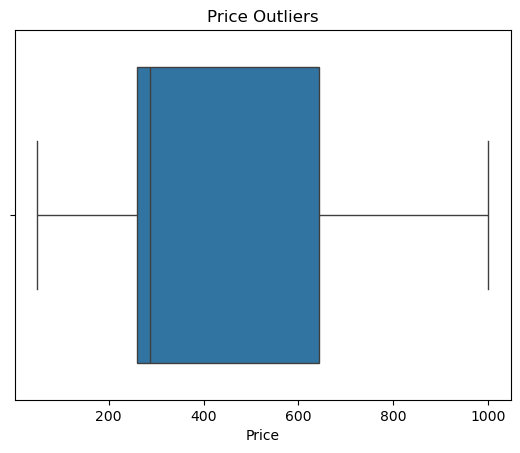

In [57]:
#Outliers for price
sns.boxplot(x=df['Price'])

plt.title("Price Outliers")
plt.show()

In [58]:
df['Transaction_Status'].unique()

array(['Failed', 'Pending', 'completed', 'Completed', 'complete'],
      dtype=object)

In [59]:
df['Product_Name'].unique()

array(['Headphones', 'Coffee ', 'Tablet', 'Tab', 'Coffee Machine',
       'Smartphone', 'Laptop', 'Coffee Ma', 'Cof', 'Smar', 'Coffee M',
       'T', 'Smartp', 'Headp', 'Smart', 'La', 'Lapt', 'Tabl', 'L', 'C',
       'Smartph', 'Hea', 'Head', 'Smartpho', 'Lapto', 'Headphon', 'Table',
       'Co', 'Headphone', 'Coffee Mac', 'Sm', 'Coffee', 'Headph', 'S',
       'Coffee Mach', 'Smartphon', 'Headpho', 'Coffee Machin', 'Coff',
       'Lap', 'H', 'He', 'Ta', 'Coffee Machi', 'Coffe', 'Sma'],
      dtype=object)

In [60]:
df['Product_Name'] = df['Product_Name'].replace(
    ['c','co','cof','coff','coffe','coffee'], 
    'coffee'
)

In [61]:
df['Product_Name'].unique()

array(['Headphones', 'Coffee ', 'Tablet', 'Tab', 'Coffee Machine',
       'Smartphone', 'Laptop', 'Coffee Ma', 'Cof', 'Smar', 'Coffee M',
       'T', 'Smartp', 'Headp', 'Smart', 'La', 'Lapt', 'Tabl', 'L', 'C',
       'Smartph', 'Hea', 'Head', 'Smartpho', 'Lapto', 'Headphon', 'Table',
       'Co', 'Headphone', 'Coffee Mac', 'Sm', 'Coffee', 'Headph', 'S',
       'Coffee Mach', 'Smartphon', 'Headpho', 'Coffee Machin', 'Coff',
       'Lap', 'H', 'He', 'Ta', 'Coffee Machi', 'Coffe', 'Sma'],
      dtype=object)

In [62]:
df.loc[df['Product_Name'].str.startswith('C'), 'Product_Name'] = 'Coffee Machine'

In [63]:
df['Product_Name'].unique()

array(['Headphones', 'Coffee Machine', 'Tablet', 'Tab', 'Smartphone',
       'Laptop', 'Smar', 'T', 'Smartp', 'Headp', 'Smart', 'La', 'Lapt',
       'Tabl', 'L', 'Smartph', 'Hea', 'Head', 'Smartpho', 'Lapto',
       'Headphon', 'Table', 'Headphone', 'Sm', 'Headph', 'S', 'Smartphon',
       'Headpho', 'Lap', 'H', 'He', 'Ta', 'Sma'], dtype=object)

In [64]:
df.loc[df['Product_Name'].str.startswith('H'), 'Product_Name'] = 'Headphones'

In [65]:
df['Product_Name'].unique()

array(['Headphones', 'Coffee Machine', 'Tablet', 'Tab', 'Smartphone',
       'Laptop', 'Smar', 'T', 'Smartp', 'Smart', 'La', 'Lapt', 'Tabl',
       'L', 'Smartph', 'Smartpho', 'Lapto', 'Table', 'Sm', 'S',
       'Smartphon', 'Lap', 'Ta', 'Sma'], dtype=object)

In [66]:
df.loc[df['Product_Name'].str.startswith('L'), 'Product_Name'] = 'Laptop'
df.loc[df['Product_Name'].str.startswith('S'), 'Product_Name'] = 'Smartphone'
df.loc[df['Product_Name'].str.startswith('T'), 'Product_Name'] = 'Tablet'

# to remove spell mistakes in product_name


In [67]:
df['Product_Name'].unique()

array(['Headphones', 'Coffee Machine', 'Tablet', 'Smartphone', 'Laptop'],
      dtype=object)

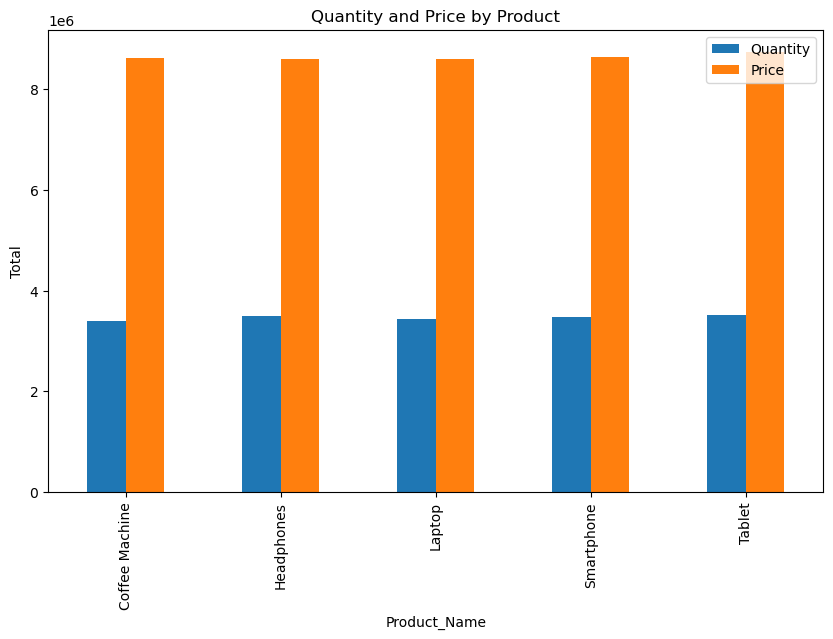

In [68]:
df.groupby('Product_Name')[['Quantity','Price']].sum().plot(kind='bar', figsize=(10,6))

plt.title("Quantity and Price by Product")
plt.ylabel("Total")
plt.show()

In [69]:
df['Quantity'] = df['Quantity'].abs()

In [70]:
df.head()

,Transaction_ID,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status,Year,Month,Date
0,T0001,C2205,Headphones,5.0,420.210000,pay pal,Failed,2024,8,2
1,T0002,C3156,Coffee Machine,469.0,445.342025,creditcard,Pending,2020,2,10
2,T0003,C2919,Tablet,4.0,810.993012,credit card,completed,2025,2,30
3,T0004,C3009,Tablet,7.0,868.608341,PayPal,Pending,2020,8,17
4,T0005,C3488,Coffee Machine,10.0,763.122449,PayPal,completed,2025,2,30


In [71]:
df['Payment_Method'].unique()

array(['pay pal', 'creditcard', 'credit card', 'PayPal', 'Cash',
       'PayPal ', 'Credit Card'], dtype=object)

In [72]:
df.loc[df['Payment_Method'].str.startswith('p'), 'Payment_Method'] = 'PayPal'
df.loc[df['Payment_Method'].str.startswith('c'), 'Payment_Method'] = 'Credit Card'
df.loc[df['Payment_Method'].str.startswith('P'), 'Payment_Method'] = 'PayPal'


In [73]:
df['Payment_Method'].unique()

array(['PayPal', 'Credit Card', 'Cash'], dtype=object)

In [74]:
df['Transaction_Status'].unique()

array(['Failed', 'Pending', 'completed', 'Completed', 'complete'],
      dtype=object)

In [75]:
df.loc[df['Transaction_Status'].str.startswith('c'), 'Transaction_Status'] = 'Completed'
df.loc[df['Transaction_Status'].str.startswith('C'), 'Transaction_Status'] = 'Completed'


In [76]:
df['Transaction_Status'].unique()

array(['Failed', 'Pending', 'Completed'], dtype=object)

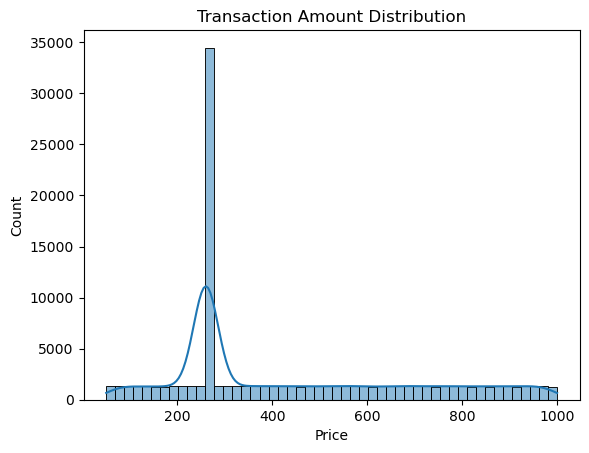

In [77]:
sns.histplot(df['Price'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

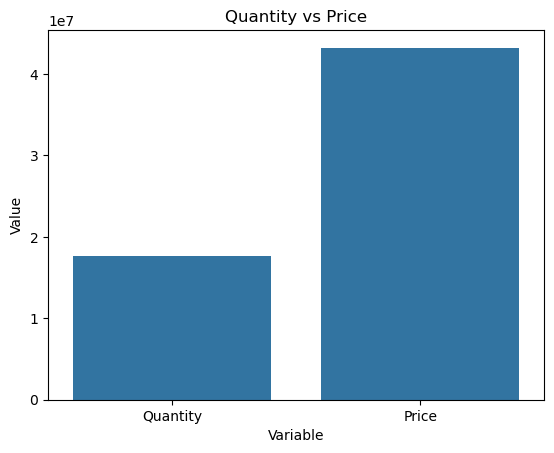

In [78]:
data = {
    'Variable': ['Quantity','Price'],
    'Value': [df['Quantity'].sum(), df['Price'].sum()]
}

sns.barplot(x='Variable', y='Value', data=data)

plt.title('Quantity vs Price')
plt.show()

In [79]:
df['Quantity'].sum()

17659978.0

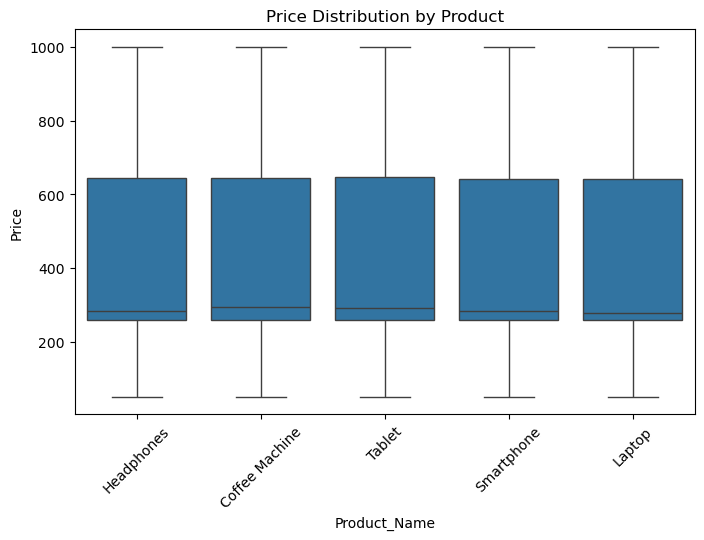

In [80]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Product_Name', y='Price', data=df)
plt.title('Price Distribution by Product')
plt.xticks(rotation=45)
plt.show()

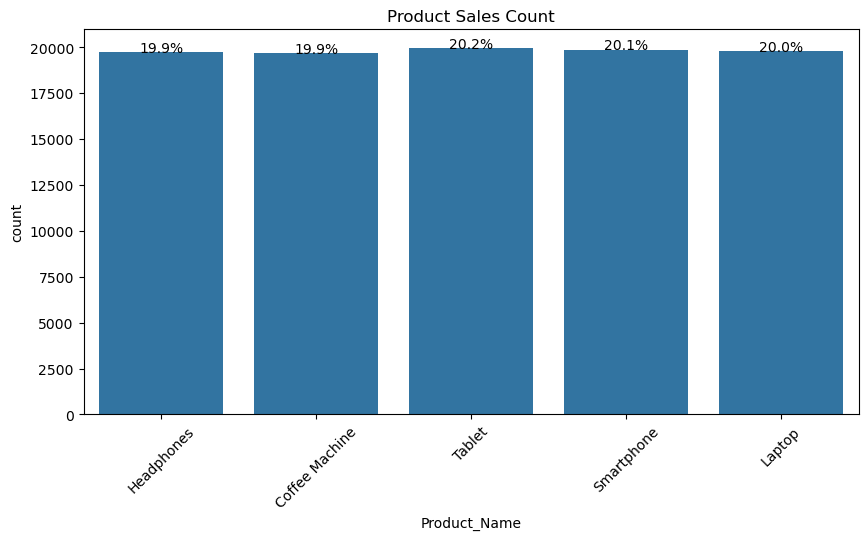

In [81]:
plt.figure(figsize=(10,5))

ax = sns.countplot(x='Product_Name', data=df)

total = len(df)

for i in ax.patches:
    percentage = f'{100 * i.get_height()/total:.1f}%'
    x = i.get_x() + i.get_width() / 2
    y = i.get_height()
    ax.text(x, y, percentage, ha='center')

plt.title('Product Sales Count')
plt.xticks(rotation=45)
plt.show()

##The Dirty Cafe Sales dataset initially contained several data quality issues including missing values, inconsistent product names, incorrect formatting, and potential outliers. These issues were addressed through data cleaning techniques such as handling null values, correcting data types, standardizing product names, and removing or analyzing outliers.

##Overall, the analysis highlights key sales trends, popular products, and pricing patterns that can help café management optimize inventory planning, pricing strategies, and promotional activities. Proper data cleaning and visualization also demonstrate the importance of preprocessing in transforming raw data into meaningful business insights.